In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/Elimited_sales_data.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,567297,84406B,CREAM CUPID HEARTS COAT HANGER,9,11/15/2025 19:30,2.75,15911,United Kingdom
1,567163,22197,POPCORN HOLDER,10,11/16/2025 7:24,0.85,13228,Netherlands
2,554498,23084,RABBIT NIGHT LIGHT,26,11/22/2025 15:12,2.08,12745,Eire
3,551304,20725,LUNCH BAG RED RETROSPOT,41,8/2/2025 23:33,1.65,12954,Portugal
4,537146,71053,WHITE METAL LANTERN,35,12/29/2025 10:54,3.39,18237,Germany


## Recreating the Revenue and date columns

In [2]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Day,Revenue
0,567297,84406B,CREAM CUPID HEARTS COAT HANGER,9,2025-11-15 19:30:00,2.75,15911,United Kingdom,2025,11,15,24.75
1,567163,22197,POPCORN HOLDER,10,2025-11-16 07:24:00,0.85,13228,Netherlands,2025,11,16,8.50
2,554498,23084,RABBIT NIGHT LIGHT,26,2025-11-22 15:12:00,2.08,12745,Eire,2025,11,22,54.08
3,551304,20725,LUNCH BAG RED RETROSPOT,41,2025-08-02 23:33:00,1.65,12954,Portugal,2025,8,2,67.65
4,537146,71053,WHITE METAL LANTERN,35,2025-12-29 10:54:00,3.39,18237,Germany,2025,12,29,118.65


## data quality checks

In [4]:
df.shape

(500, 12)

In [5]:
df.dtypes

InvoiceNo               int64
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID              int64
Country                   str
Year                    int32
Month                   int32
Day                     int32
Revenue               float64
dtype: object

In [6]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Year           0
Month          0
Day            0
Revenue        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,500.000000,500.000000
mean,38.706000,4.865880
std,65.912096,5.268293
min,1.000000,0.550000
25%,15.000000,1.690000
50%,27.000000,2.080000
75%,40.000000,4.650000
max,493.000000,18.000000


### q1: How does revenue change over time?

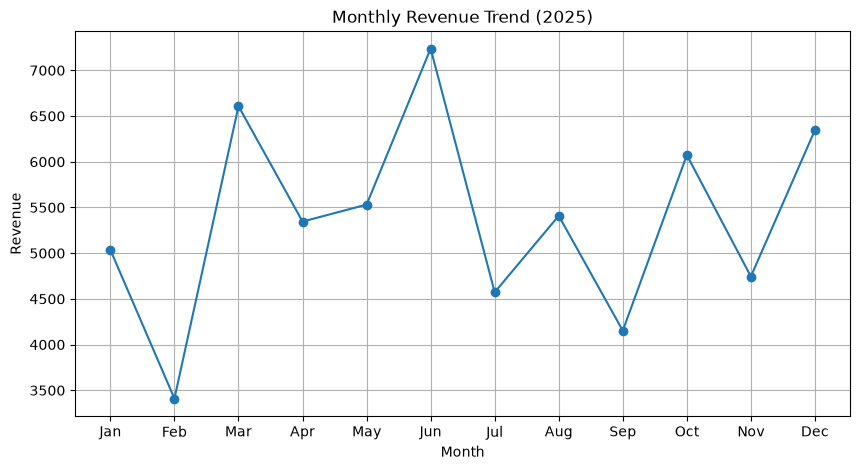

In [10]:
import calendar

monthly_revenue = df.groupby("Month")["Revenue"].sum()
month_names = [calendar.month_abbr[m] for m in monthly_revenue.index]

plt.figure(figsize=(10, 5))
plt.plot(month_names, monthly_revenue.values, marker="o")
plt.title("Monthly Revenue Trend (2025)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

June had the highest revenue, while February had the lowest. Revenue goes up and down across the year, which could help with planning stock and sales campaigns around the busier months.

### q2: Which 10 products generate the most revenue?

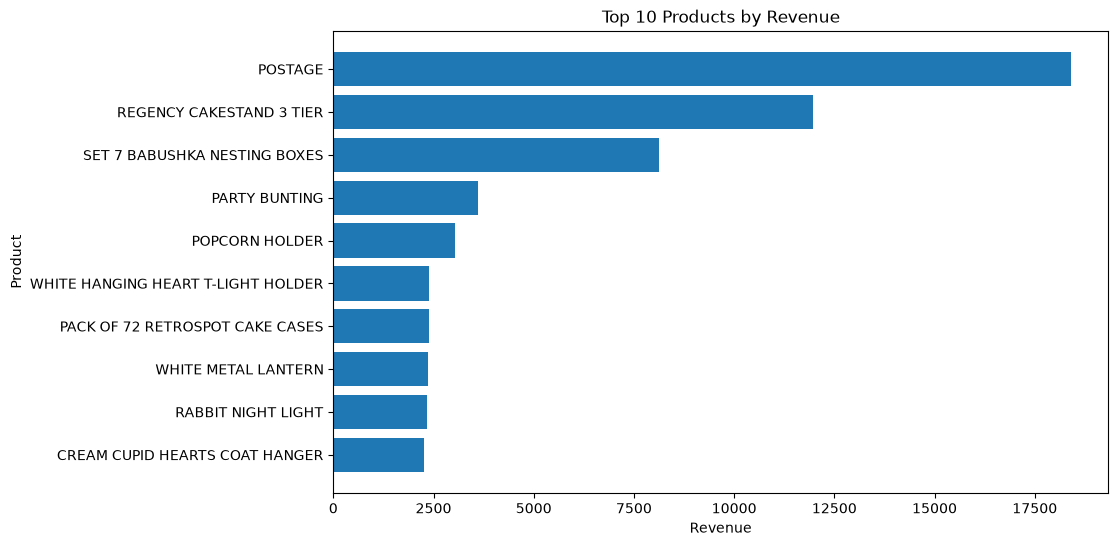

In [11]:
top_10_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(top_10_products.index, top_10_products.values)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.show()

POSTAGE made the most money, followed by REGENCY CAKESTAND 3 TIER and SET 7 BABUSHKA NESTING BOXES. A few products bring in most of the revenue, so the business should pay close attention to these top sellers.

### q3: Which countries generate the most revenue?

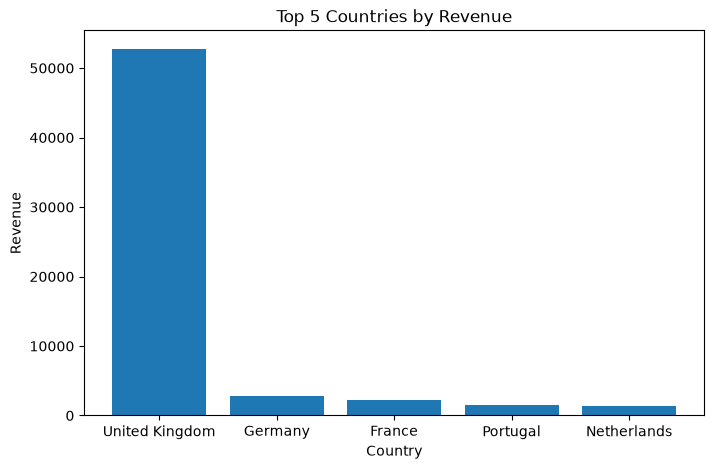

In [12]:
top_countries = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8, 5))
plt.bar(top_countries.index, top_countries.values)
plt.title("Top 5 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

The United Kingdom brings in far more revenue than any other country, followed by Germany, France, Portugal, and Netherlands. This shows the business relies heavily on UK customers, so any changes in the UK market could have a big impact on overall sales.